In [2]:
import os
import matplotlib.pyplot as plt

In [3]:
os.makedirs("reports", exist_ok=True)

1. Map Cluster Meaning

Example interpretation:

Cluster 0 → High Engagement
Cluster 1 → Moderate Users
Cluster 2 → Low / At Risk
Cluster 3 → Occasional Users

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
df = pd.read_csv("../data/processed/cleaned_data.csv")
features = [
    "sessions_per_week",
    "avg_session_duration_min",
    "daily_active_minutes",
    "feature_clicks_per_session",
    "engagement_score",
    "days_since_last_login"
]

X = df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=4, random_state=42)

df["cluster"] = kmeans.fit_predict(X_scaled)

2. Customer Lists per Cluster

In [5]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)

In [6]:
high_users = df[df["cluster"] == 0]
moderate_users = df[df["cluster"] == 1]
low_users = df[df["cluster"] == 2]
occasional_users = df[df["cluster"] == 3]

3. Save Clustered Dataset

1️. Check cluster distribution (how many users in each group)

In [7]:
df["cluster"].value_counts()

cluster
2    14478
1    12329
3    12317
0    10876
Name: count, dtype: int64

This shows how many users belong to each behavioral segment.

2️. Analyze average behavior per cluster

In [9]:
cluster_summary = df.groupby("cluster")[[
"sessions_per_week",
"avg_session_duration_min",
"daily_active_minutes",
"feature_clicks_per_session",
"pages_viewed_per_session",
"engagement_score",
"churn_risk_score"
]].mean()

cluster_summary

,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,pages_viewed_per_session,engagement_score,churn_risk_score
cluster,,,,,,,
0,8.054800,14.645619,45.248520,16.426903,13.430857,66.249486,0.501635
1,8.413902,13.629173,34.749040,11.357937,13.405872,54.604163,0.498850
2,7.944882,12.754868,43.438612,10.074665,13.488534,64.009166,0.504114
3,7.600796,11.813533,57.544759,11.053341,13.550053,75.225428,0.498259


This helps understand how engagement and activity differ across clusters.

3️. Identify High-Value Customers

In [10]:
high_value_users = df[df["cluster"] == 0]

high_value_users[[
"user_id",
"sessions_per_week",
"avg_session_duration_min",
"engagement_score"
]].head()

,user_id,sessions_per_week,avg_session_duration_min,engagement_score
3,100003,5,3.98,62.81
5,100005,12,10.51,91.45
7,100007,6,6.81,84.81
14,100014,5,17.92,51.33
23,100023,13,11.32,67.32


Business insight:

* High engagement

* Frequent sessions

* Loyal users

Action:
Loyalty programs, premium subscriptions, exclusive offers

4️. Identify Low-Engagement / At-Risk Users

In [11]:
at_risk_users = df[df["cluster"] == 2]

at_risk_users[[
"user_id",
"sessions_per_week",
"days_since_last_login",
"churn_risk_score"
]].head()

,user_id,sessions_per_week,days_since_last_login,churn_risk_score
0,100000,5,20,0.31
1,100001,8,7,0.87
12,100012,5,1,0.07
18,100018,10,14,0.14
22,100022,4,8,0.79


Business insight:

* Low usage

* Long inactivity

* High churn risk

Action:
Retention campaigns, reminders, discounts

5️. Identify Moderate Engagement Users

In [12]:
moderate_users = df[df["cluster"] == 1]

moderate_users[[
"user_id",
"sessions_per_week",
"engagement_score"
]].head()

,user_id,sessions_per_week,engagement_score
2,100002,12,42.49
4,100004,10,38.21
6,100006,8,63.30
9,100009,8,55.92
10,100010,9,56.02


Business insight:

* Consistent usage

* Average engagement

Action:
Personalized notifications and feature recommendations

6️. Identify Occasional Users

In [13]:
occasional_users = df[df["cluster"] == 3]

occasional_users[[
"user_id",
"sessions_per_week",
"pages_viewed_per_session"
]].head()

,user_id,sessions_per_week,pages_viewed_per_session
8,100008,7,19
11,100011,6,8
16,100016,7,11
17,100017,6,24
19,100019,7,16


Business insight:

* Irregular usage

Action:
Re-engagement campaigns and onboarding improvements

7️. Customer-Level Targeting

In [14]:
df[["user_id","cluster"]].head()

,user_id,cluster
0,100000,2
1,100001,2
2,100002,1
3,100003,0
4,100004,1


Each user is assigned a cluster, enabling targeted marketing instead of generic campaigns.

8️. Visualization

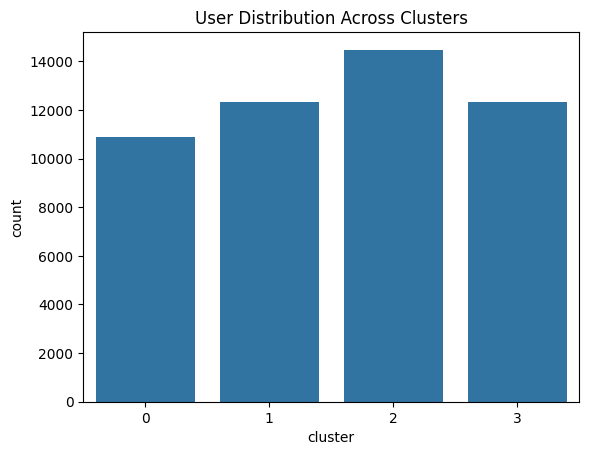

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x="cluster")
plt.title("User Distribution Across Clusters")
plt.show()

Shows the size of each behavioral segment.